## Import the required modules

In [96]:
import matplotlib.pyplot as plt
import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any, Dict, Callable
from QMAP_tools.qmap_inspector import QMAPInspector

In [97]:
# Not required but improved the default layout of plots
import scienceplots
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

In [98]:
qm = QMAPInspector()
# Load the helper class which by default has the standard relative paths of the database files so should work out of the box
# in most cases, however if the data is stored else where just use the init kwargs to set the correct path

In [99]:
qm.full_db.filter(pl.col("i") == 1).collect()
# The full database contains all the data needed to make the agg_db and some. It is very important that you do not try load
# the full database into memory so when previewing a standard way is to just filter by pl.col("i") == 1 which restricts the
# database to 1 / 8192 of its full size and therefore can be fully loaded into memory. We are still able to do operations
# on this dataset as you will see later leveraging the LazyFrame.

i,j,face,area,TIR detailed_survey tri_num,TIR detailed_survey band depth 350,TIR detailed_survey band depth 440,TIR detailed_survey slope 1000,TIR detailed_survey ratio 1000,TIR detailed_survey sigma band depth 350,TIR detailed_survey sigma band depth 440,TIR detailed_survey sigma slope 1000,TIR detailed_survey sigma ratio 1000,TIR recona tri_num,TIR recona band depth 350,TIR recona band depth 440,TIR recona slope 1000,TIR recona ratio 1000,TIR recona sigma band depth 350,TIR recona sigma band depth 440,TIR recona sigma slope 1000,TIR recona sigma ratio 1000,TIR reconb tri_num,TIR reconb band depth 350,TIR reconb band depth 440,TIR reconb slope 1000,TIR reconb ratio 1000,TIR reconb sigma band depth 350,TIR reconb sigma band depth 440,TIR reconb sigma slope 1000,TIR reconb sigma ratio 1000,VNIR detailed_survey tri_num,VNIR detailed_survey band depth,VNIR detailed_survey reflectance,VNIR detailed_survey slope1 poly,VNIR detailed_survey slope2 poly,VNIR detailed_survey sigma band depth,…,VNIR recona sigma slope2 poly,VNIR reconc tri_num,VNIR reconc band depth,VNIR reconc reflectance,VNIR reconc slope1 poly,VNIR reconc slope2 poly,VNIR reconc sigma band depth,VNIR reconc sigma reflectance,VNIR reconc sigma slope1 poly,VNIR reconc sigma slope2 poly,uint8_reflectance,32bit_reflectance,positions_x,positions_y,positions_z,detection_lod_level,detection_lod_code,boulder_id,Gamma,Tau,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples,TIR detailed_survey tri_num alpha,TIR recona tri_num alpha,TIR reconb tri_num alpha,VNIR detailed_survey tri_num alpha,VNIR recona tri_num alpha,VNIR reconc tri_num alpha
u32,u32,str,f32,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,…,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u8,f32,f32,f32,f32,u8,str,u32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32,u32,u32,u32,u32,u32,u32
1,2001,"""negx""",0.001015,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,52,0.009051,0.079066,0.154651,-0.154623,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2002,"""negx""",0.001057,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,63,0.010972,0.079029,0.154657,-0.154623,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2003,"""negx""",0.001048,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,74,0.012779,0.07899,0.154662,-0.154624,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2004,"""negx""",0.000999,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,88,0.015247,0.078953,0.154663,-0.154628,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,1920,"""negx""",0.000975,27132,1.003123,1.01109,1.001736,null,0.001058,0.000682,0.000824,null,432631,null,null,null,null,null,null,null,null,432631,nu

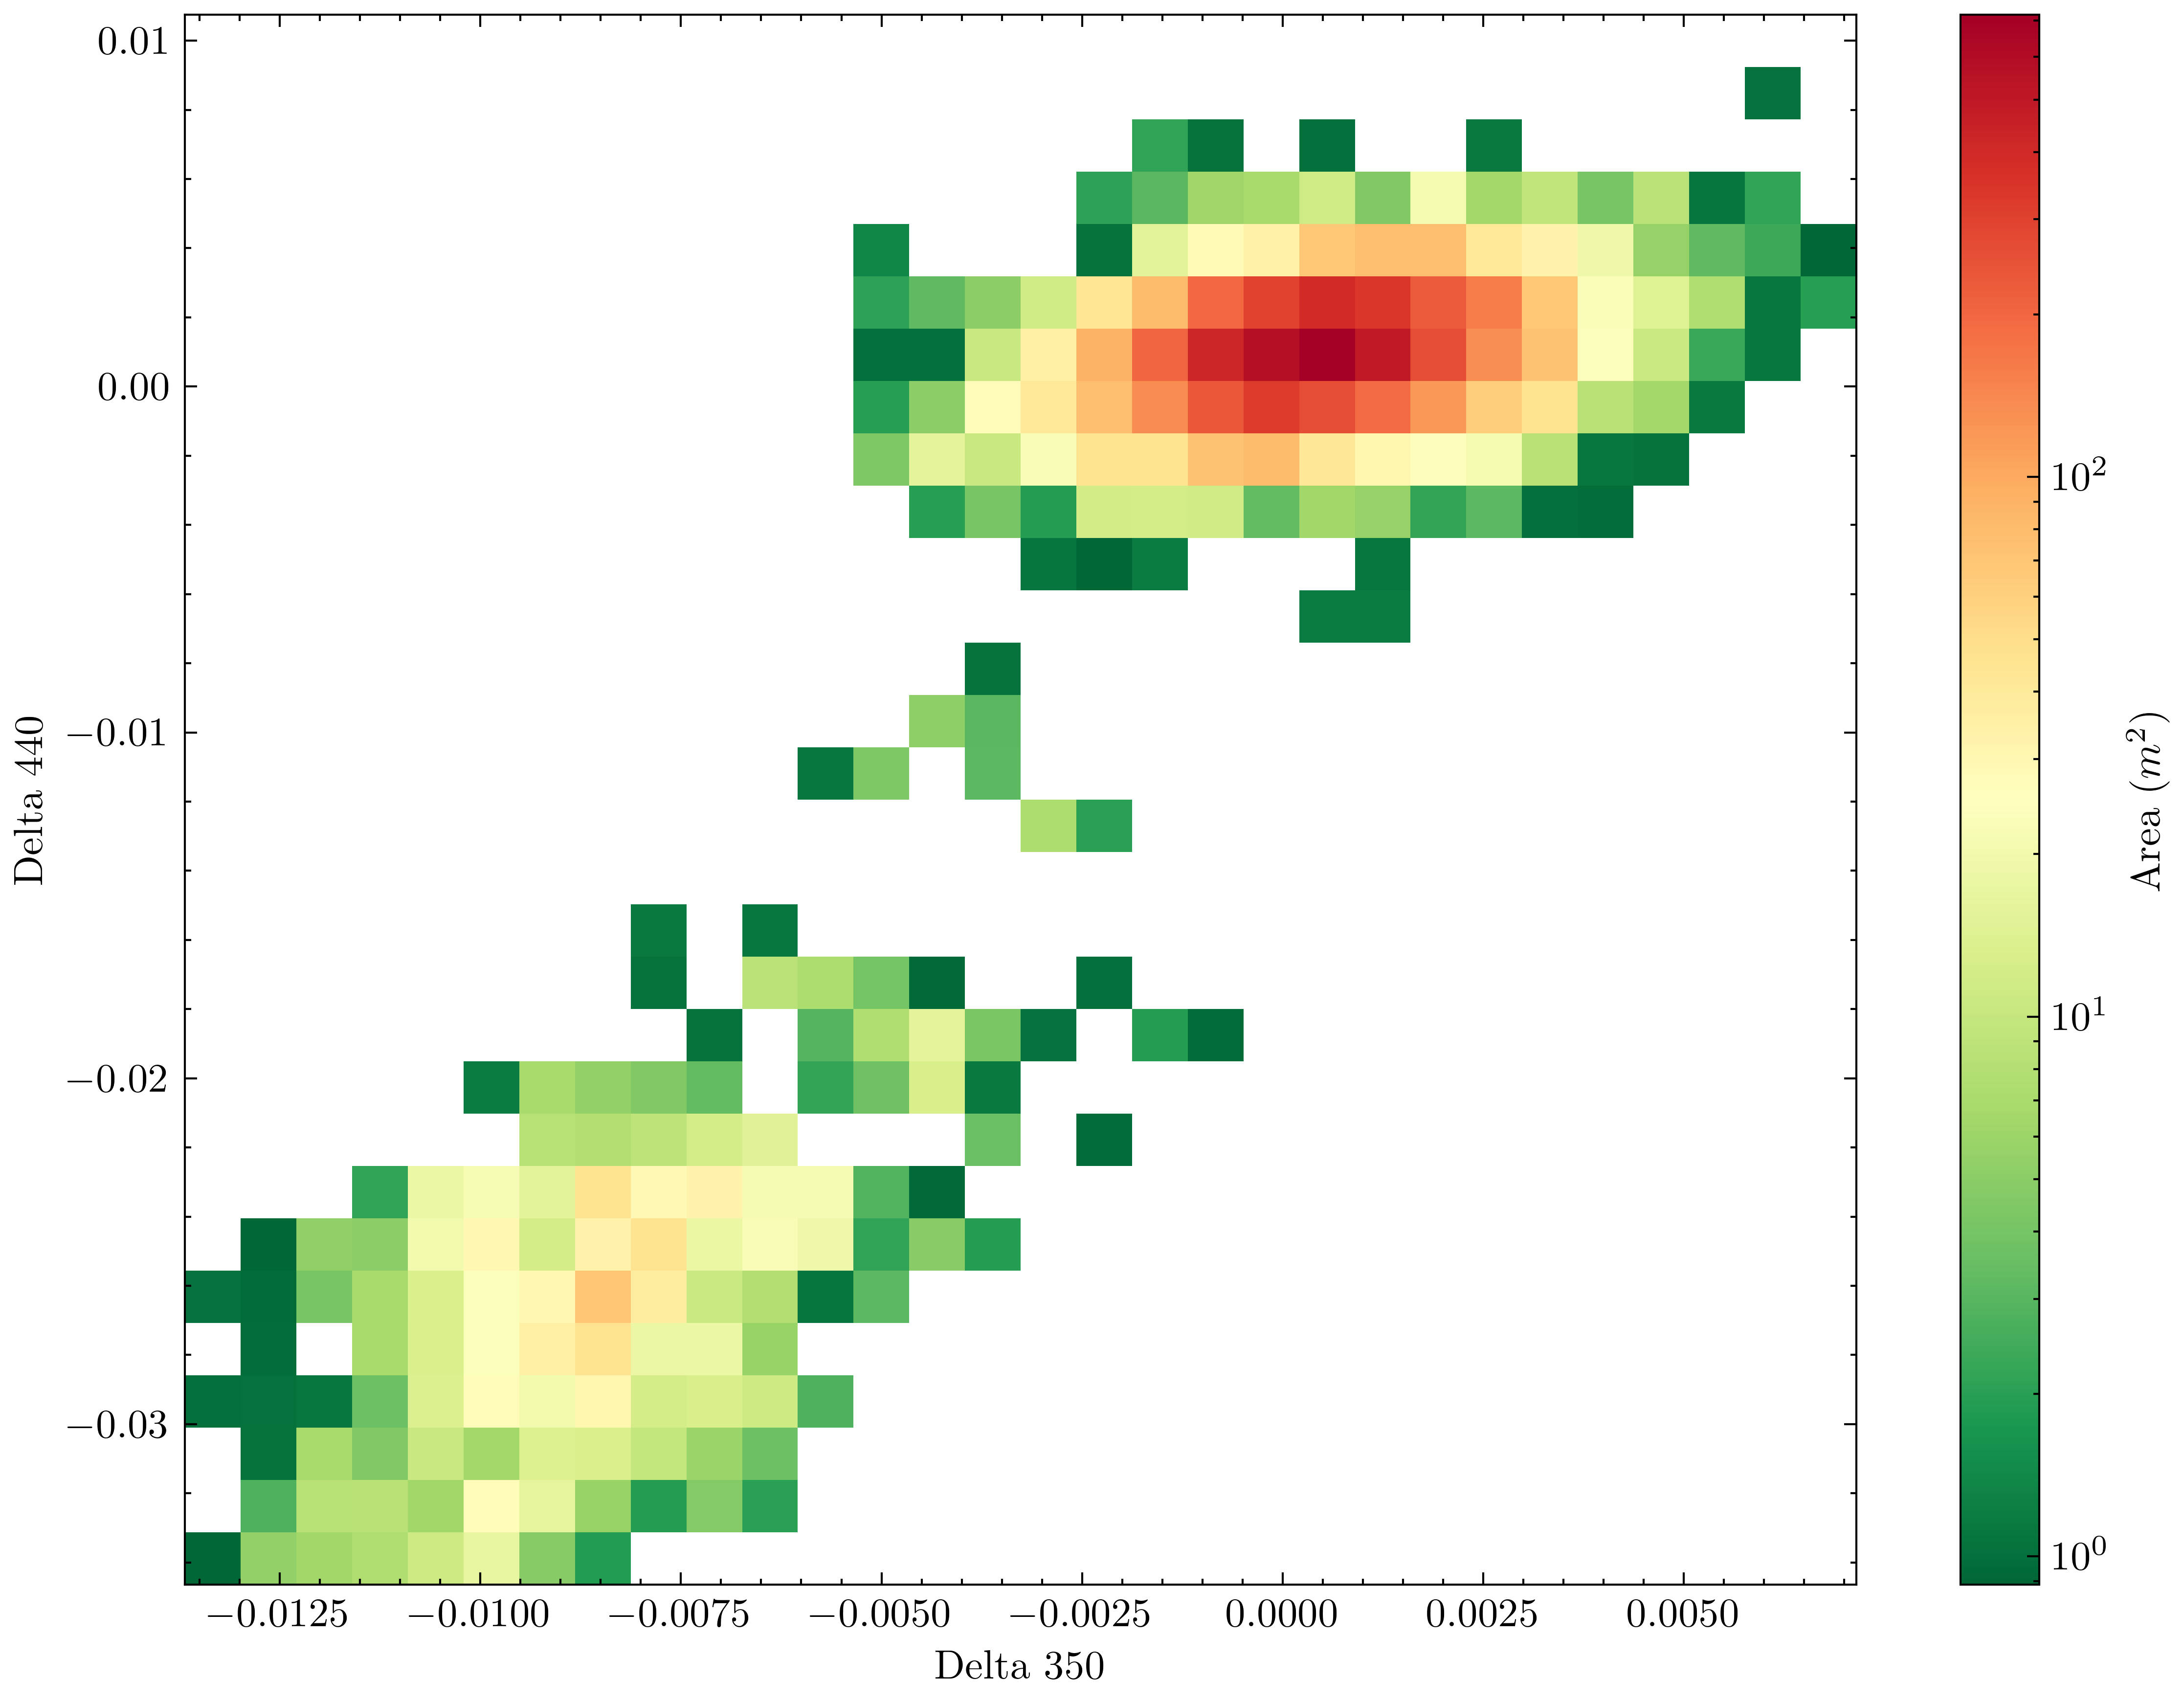

In [100]:
from matplotlib import colors

# Define your items
x_item, y_item = "Delta 350", "Delta 440"

custom_lf = qm.full_db.with_columns(
    (pl.col("TIR recona band depth 350") - pl.col("TIR reconb band depth 350")).alias(x_item),
    (pl.col("TIR recona band depth 440") - pl.col("TIR reconb band depth 440")).alias(y_item)
)


# Get the hist data (will be weighted by the row area by default can edit using the weight_col)
counts, x_edges, y_edges = qm.get_column_hist2d(
    columns=(x_item, y_item),
    bin_ranges=(
        qm.get_column_extrema(x_item, custom_lf=custom_lf), 
        qm.get_column_extrema(y_item, custom_lf=custom_lf)
        ),
    bin_numbers=(30, 30),
    custom_lf=custom_lf
)

plt.figure(figsize=(8, 6))

plt.pcolormesh(
    x_edges,
    y_edges,
    counts.T,        # transpose because pcolormesh expects (y, x)
    shading="auto",
    cmap="RdYlGn_r",
    norm = colors.LogNorm()
)

plt.xlabel(x_item)
plt.ylabel(y_item)
plt.colorbar(label = r"Area ($m^2$)")
plt.tight_layout()
plt.show()

In [101]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = (
    custom_lf
    .filter(
        pl.col("Delta 350").is_not_nan(),
        pl.col("Delta 440").is_not_nan()
    )
    .select(["Delta 350", "Delta 440"])
    .unique()
    .collect(engine="streaming")
)

# Extract features for clustering
features = (
    X
    .select(["Delta 350", "Delta 440"])
    .to_numpy()
)

# Scale the two dimensions
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# K-means classification
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(features_scaled)

# Add labels back into Polars dataframe
X = X.with_columns(
    pl.Series("population", labels)
)

# Cluster centres back in original units
centres = scaler.inverse_transform(kmeans.cluster_centers_)

print(centres)

[[ 0.00042194  0.00095459]
 [-0.00845803 -0.02651719]]


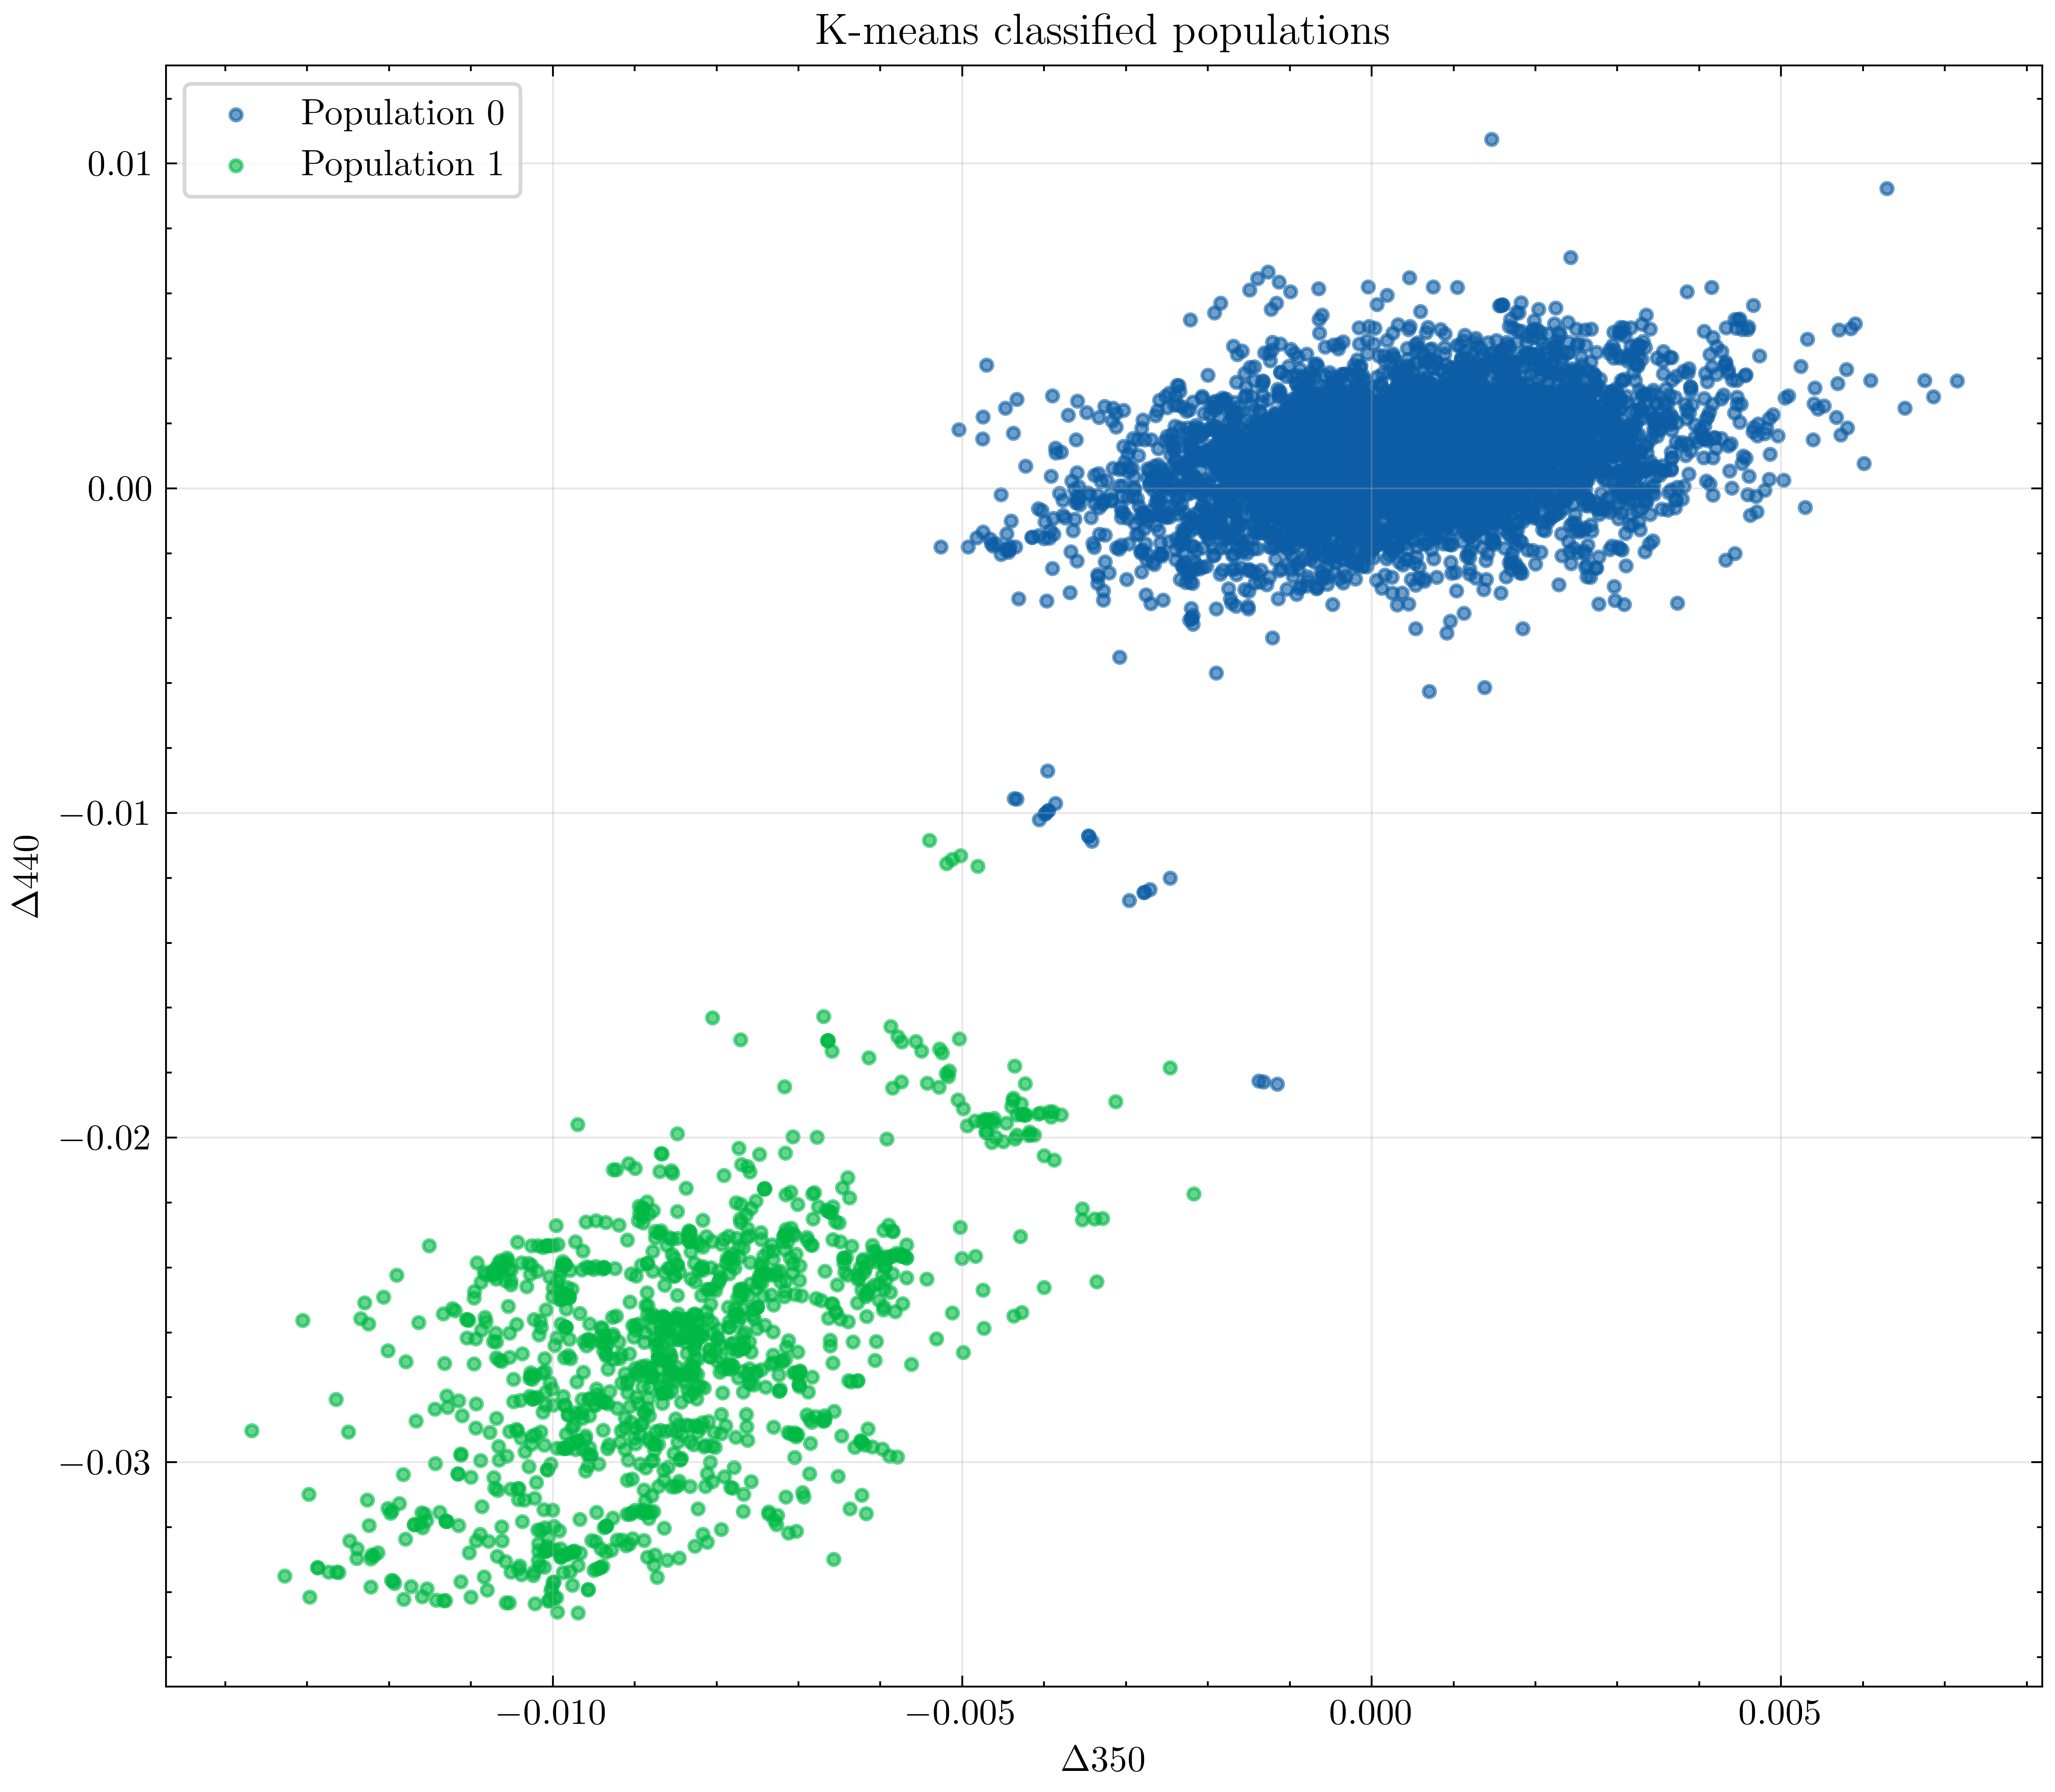

In [102]:
import matplotlib.pyplot as plt

df_plot = X.to_pandas()

plt.figure(figsize=(8, 7))

for pop, group in df_plot.groupby("population"):
    plt.scatter(
        group["Delta 350"],
        group["Delta 440"],
        s=10,
        alpha=0.6,
        label=f"Population {pop}"
    )

plt.xlabel(r"$\Delta 350$")
plt.ylabel(r"$\Delta 440$")
plt.title("K-means classified populations")

plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
custom_lf_classified = (
    custom_lf
    .join(
        X.select(["Delta 350", "Delta 440", "population"]).lazy(),
        on=["Delta 350", "Delta 440"],
        how="left"
    )
)

shadow_filter = pl.col("32bit_reflectance") > 0.01
bright_spot_filter = pl.col("32bit_reflectance") < 0.04
metric = (pl.col("32bit_reflectance"))
filtered_metric = metric.filter(shadow_filter, bright_spot_filter)

thre = 0.0165
numb_B = (filtered_metric > thre).sum()
numb_A = (filtered_metric < thre).sum()

boulder_id_cluster = (
    custom_lf_classified
    .filter(pl.col("population").is_not_null())
    .group_by("boulder_id")
    .agg(
            pl.col("population").max(),
            (
                (
                    (numb_B.cast(pl.Float64) - numb_A.cast(pl.Float64))
                    /
                    (numb_B.cast(pl.Float64) + numb_A.cast(pl.Float64))
                )
                .alias("test")
            )
            .alias("test")
        )
    .collect(engine="streaming")
)

df = (
    boulder_id_cluster
    .join(qm.agg_db, on="boulder_id")
    .filter(pl.col("population").is_not_null())
)

In [116]:
print(boulder_id_cluster["test"].is_not_nan().mean())
print(boulder_id_cluster["test"].is_not_nan().std())

0.9952854897852279
0.06850622656317784


In [ ]:


# # output directories
# base_path = Path(".plots/which_group/render")

# for group in [0, 1]:
#     group_path = base_path / f"group_{group}"
#     group_path.mkdir(parents=True, exist_ok=True)

#     # sample 20 boulders from this population
#     sample_ids = (
#         df
#         .filter(pl.col("population") == group)
#         .select("boulder_id")
#         .sample(n=10, seed=42)
#         .to_series()
#     )

#     for boulder_id in sample_ids:
#         fig_export_path = group_path / f"{boulder_id}.png"

#         qm.render_multi_plot(
#             boulder_id,
#             "population",
#             zoom_factor=100,
#             custom_lf=custom_lf_classified,
#             fig_export_path=fig_export_path,
#         )


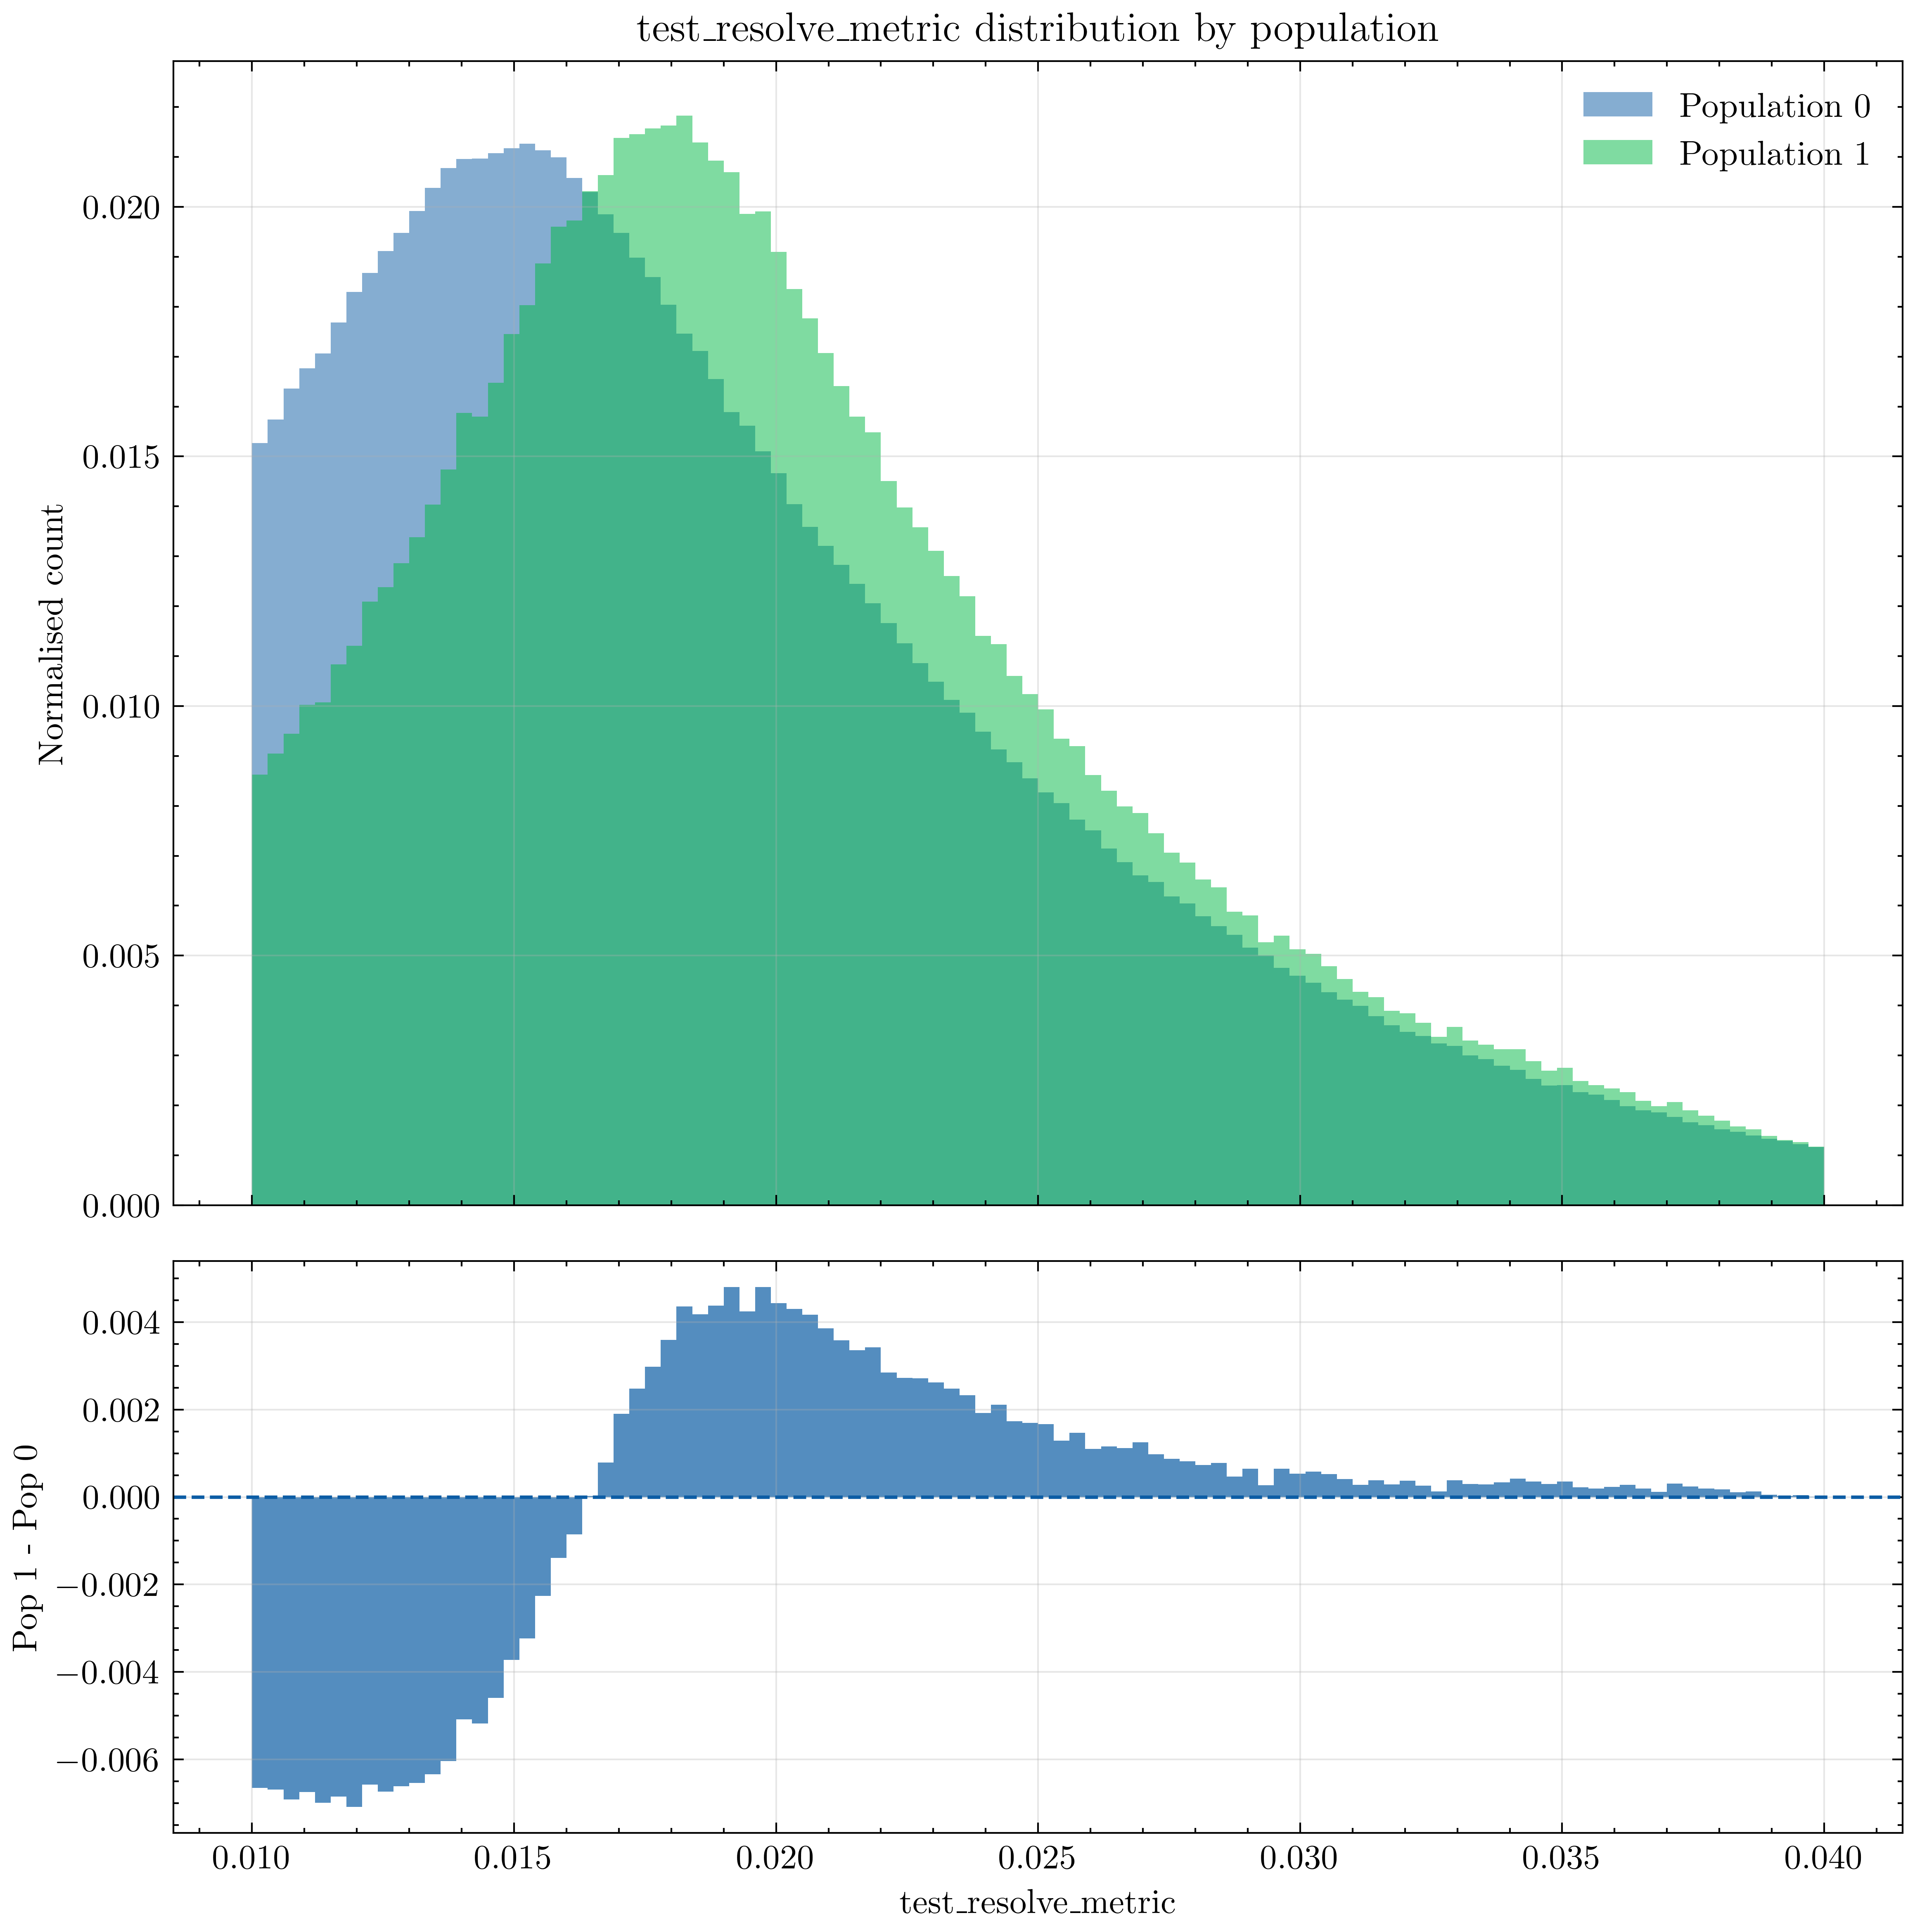

0.22623161922411825


In [118]:
import numpy as np
import matplotlib.pyplot as plt

# Define item
item = "test_resolve_metric"
custom_lf_for_32_r = custom_lf_classified.filter(
        pl.col("population").is_not_null(),

        pl.col("32bit_reflectance") > 0.01,
        pl.col("32bit_reflectance") < 0.04
    ).with_columns(
        (pl.col("32bit_reflectance")).alias("test_resolve_metric")
    )

# Common range and bins
item_range = qm.get_column_extrema(item, custom_lf=custom_lf_for_32_r)

hist_data = {}

# Calculate both histograms with identical bins
for pop in [0, 1]:
    counts, bins = qm.get_column_hist(
        column=item,
        bin_range=item_range,
        bin_number=100,
        custom_lf=custom_lf_for_32_r.filter(pl.col("population") == pop)
    )

    hist_data[pop] = counts / np.sum(counts)

bins_centres = (bins[:-1] + bins[1:]) / 2
width = np.diff(bins)

# Difference
difference = hist_data[1] - hist_data[0]

# Plot
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# Histograms
ax1.bar(
    bins[:-1],
    hist_data[0],
    width=width,
    align="edge",
    alpha=0.5,
    label="Population 0"
)

ax1.bar(
    bins[:-1],
    hist_data[1],
    width=width,
    align="edge",
    alpha=0.5,
    label="Population 1"
)

ax1.set_ylabel("Normalised count")
ax1.set_title(f"{item} distribution by population")
ax1.legend()
ax1.grid(alpha=0.3)

# Difference
ax2.bar(
    bins[:-1],
    difference,
    width=width,
    align="edge",
    alpha=0.7
)

ax2.axhline(0, linestyle="--")
ax2.set_xlabel(item)
ax2.set_ylabel("Pop 1 - Pop 0")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(np.abs(difference).sum())

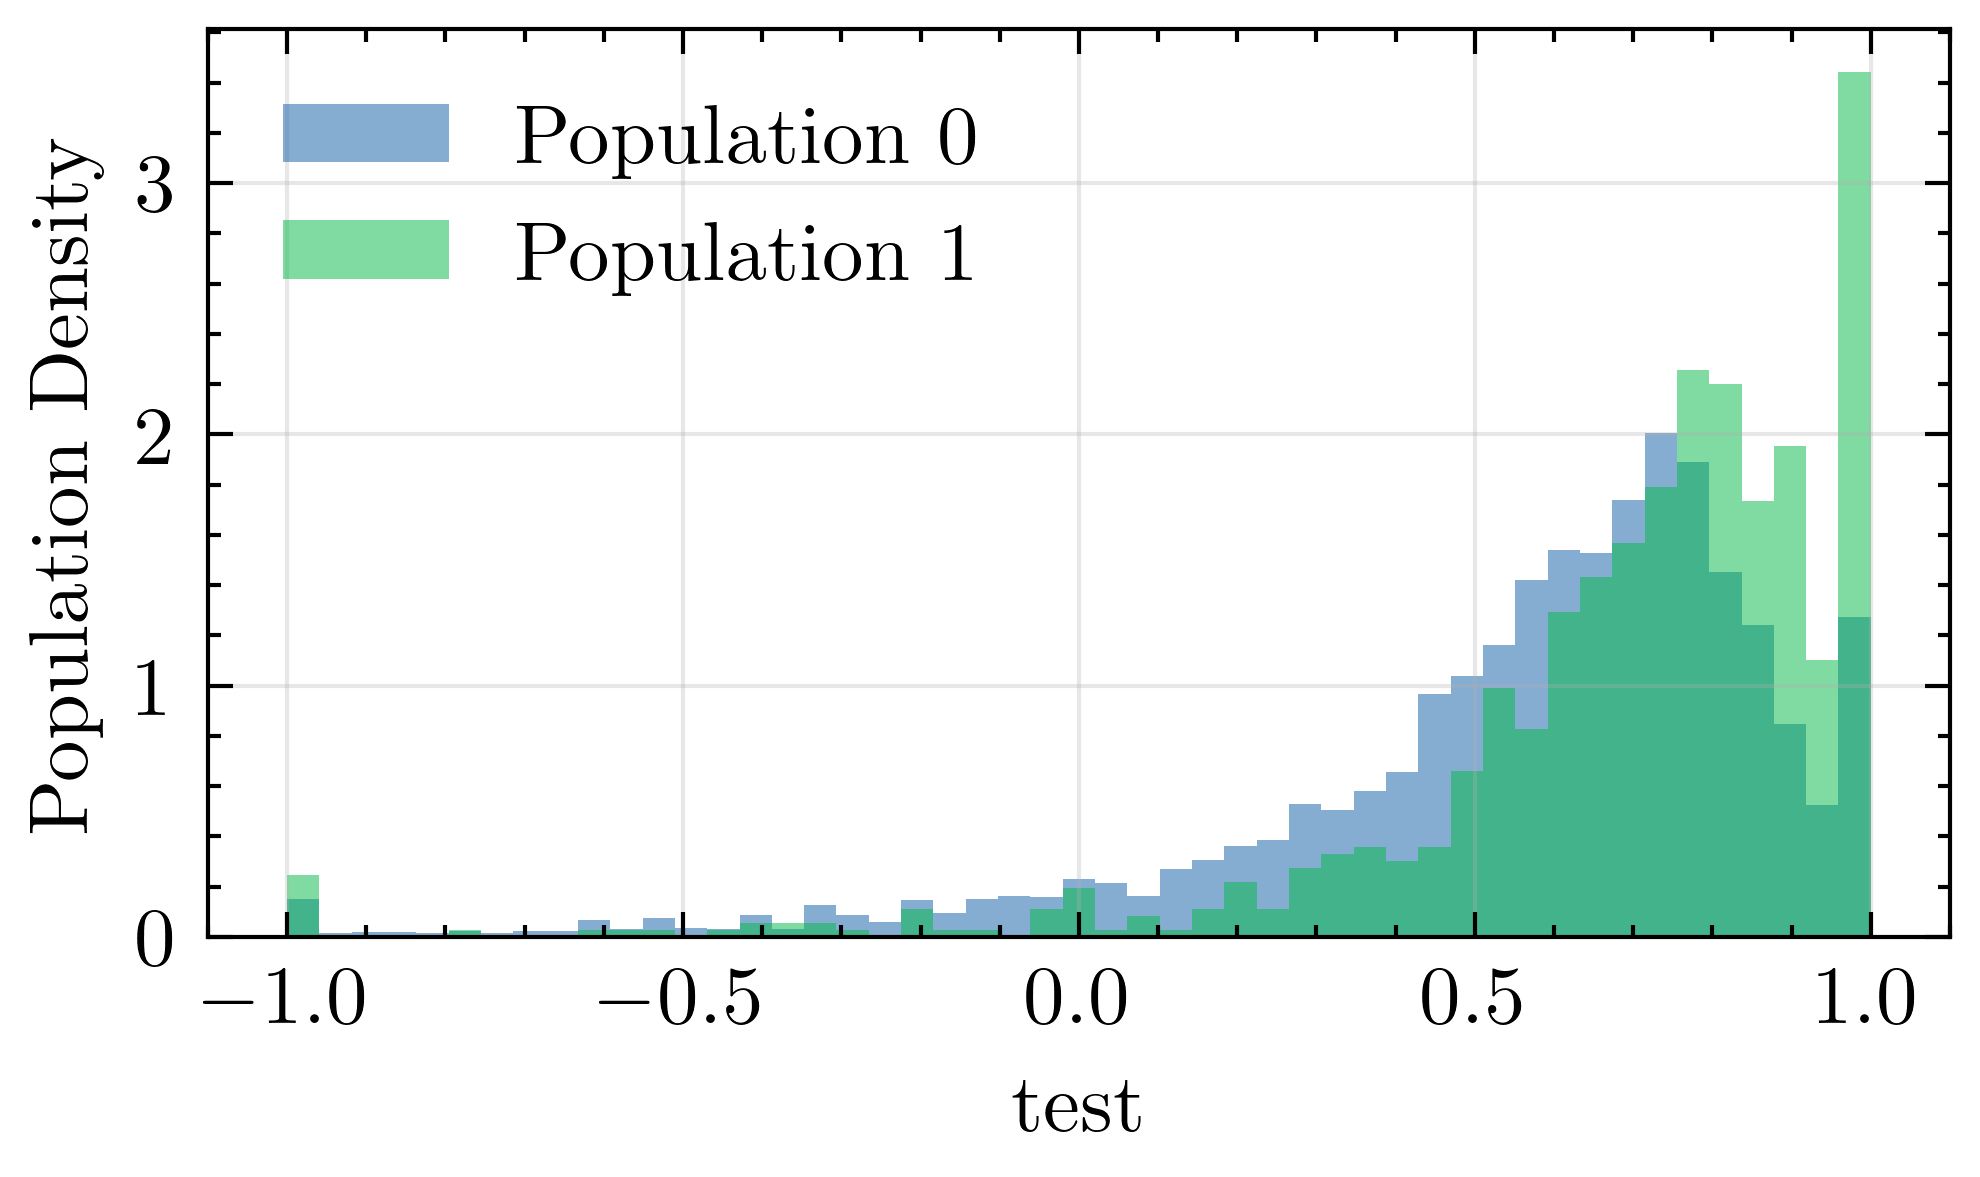

In [119]:
# common bins
gamma_min = -1
gamma_max = 1
bins = np.linspace(gamma_min, gamma_max, 50)

for pop in df["population"].unique().sort():
    gamma = (
        df
        .filter(pl.col("population") == pop)
        ["test"]
        .to_numpy()
    )

    plt.hist(
        gamma,
        bins=bins,
        alpha=0.5,
        density=True,
        label=f"Population {pop}"
    )

# plt.yscale("log")
plt.xlabel(r"test")
plt.ylabel("Population Density")
# plt.title("Gamma distribution by k-means population")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [135]:
from sklearn.metrics import roc_auc_score

data = (
    df
    .filter(pl.col("number_of_samples") > 10)
)

test_values = data["test"].to_numpy()
true_pop = data["population"].to_numpy()

# remove invalid values
mask = np.isfinite(test_values)

test_values = test_values[mask]
true_pop = true_pop[mask]

# calculate AUC directly from the empirical test values
auc = roc_auc_score(
    true_pop,
    test_values
)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.649


In [ ]:
filter_350 = qm.full_db.filter(
    pl.col("TIR recona band depth 350").is_not_nan(),
    pl.col("TIR recona band depth 350") < 0.997
).collect()

filter_440 = qm.full_db.filter(
    pl.col("TIR recona band depth 440").is_not_nan(),
    pl.col("TIR recona band depth 440") < 0.995
).collect()

filter_total = qm.full_db.filter(
    pl.col("TIR recona band depth 440").is_not_nan(),
    pl.col("TIR recona band depth 440") < 0.995,
    pl.col("TIR recona band depth 350").is_not_nan(),
    pl.col("TIR recona band depth 350") < 0.997
).collect()

filter_total

i,j,face,area,TIR detailed_survey tri_num,TIR detailed_survey band depth 350,TIR detailed_survey band depth 440,TIR detailed_survey slope 1000,TIR detailed_survey ratio 1000,TIR detailed_survey sigma band depth 350,TIR detailed_survey sigma band depth 440,TIR detailed_survey sigma slope 1000,TIR detailed_survey sigma ratio 1000,TIR recona tri_num,TIR recona band depth 350,TIR recona band depth 440,TIR recona slope 1000,TIR recona ratio 1000,TIR recona sigma band depth 350,TIR recona sigma band depth 440,TIR recona sigma slope 1000,TIR recona sigma ratio 1000,TIR reconb tri_num,TIR reconb band depth 350,TIR reconb band depth 440,TIR reconb slope 1000,TIR reconb ratio 1000,TIR reconb sigma band depth 350,TIR reconb sigma band depth 440,TIR reconb sigma slope 1000,TIR reconb sigma ratio 1000,VNIR detailed_survey tri_num,VNIR detailed_survey band depth,VNIR detailed_survey reflectance,VNIR detailed_survey slope1 poly,VNIR detailed_survey slope2 poly,VNIR detailed_survey sigma band depth,…,VNIR recona sigma slope2 poly,VNIR reconc tri_num,VNIR reconc band depth,VNIR reconc reflectance,VNIR reconc slope1 poly,VNIR reconc slope2 poly,VNIR reconc sigma band depth,VNIR reconc sigma reflectance,VNIR reconc sigma slope1 poly,VNIR reconc sigma slope2 poly,uint8_reflectance,32bit_reflectance,positions_x,positions_y,positions_z,detection_lod_level,detection_lod_code,boulder_id,Gamma,Tau,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples,TIR detailed_survey tri_num alpha,TIR recona tri_num alpha,TIR reconb tri_num alpha,VNIR detailed_survey tri_num alpha,VNIR recona tri_num alpha,VNIR reconc tri_num alpha
u32,u32,str,f32,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,…,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u8,f32,f32,f32,f32,u8,str,u32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32,u32,u32,u32,u32,u32,u32
4311,1961,"""negx""",0.003139,26811,1.003208,1.014931,0.997036,null,0.001524,0.000938,0.001241,null,429293,0.9944,0.99336,null,0.99652,0.007255,0.001887,null,0.002794,429293,null,null,null,null,null,null,null,null,107381,null,null,null,null,null,…,null,1717721,null,null,null,null,null,null,null,null,120,0.020696,0.121025,0.232304,0.012196,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,7068,422,422,1740,422,117
4307,1958,"""negx""",0.002895,26811,1.003208,1.014931,0.997036,null,0.001524,0.000938,0.001241,null,429293,0.9944,0.99336,null,0.99652,0.007255,0.001887,null,0.002794,429293,null,null,null,null,null,null,null,null,107381,null,null,null,null,null,…,null,1717721,null,null,null,null,null,null,null,null,106,0.018368,0.121185,0.23227,0.011966,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,7068,422,422,1740,422,117
4306,1961,"""negx""",0.002766,26811,1.003208,1.014931,0.997036,null,0.001524,0.000938,0.001241,null,429293,0.9944,0.99336,null,0.99652,0.007255,0.001887,null,0.002794,429293,null,null,null,null,null,null,null,null,107381,null,null,null,null,null,…,null,1717721,null,null,null,null,null,null,null,null,170,0.029439,0.121041,0.232334,0.011916,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,7068,422,422,1740,422,117
4305,1957,"""negx""",0.0029,26811,1.003208,1.014931,0.997036,null,0.001524,0.000938,0.001241,null,429293,0.9944,0.99336,null,0.99652,0.007255,0.001887,null,0.002794,429293,null,null,null,null,null,null,null,null,107381,null,null,null,null,null,…,null,1717721,null,null,null,null,null,null,null,null,122,0.021167,0.121239,0.232261,0.011856,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,7068,422,422,1740,422,117
4305,1955,"""negx""",0.002711,26811,1.003208,1.014931,0.997036,null,0.001524,0.000938,0.001241,null,429293,0.9944,0.99336,null,0.99652,0.007255,0.001887,null,0.002794,429293,null,null,null,null,null,null,null,null,107381,null,null,null,null,null,…,null,1717721,null,

In [ ]:
mix = 0.3

cond_350 = (
    pl.col("TIR recona band depth 350").is_not_nan()
    & (pl.col("TIR recona band depth 350") < 0.997)
)

cond_440 = (
    pl.col("TIR recona band depth 440").is_not_nan()
    & (pl.col("TIR recona band depth 440") < 0.995)
)

highlight_expr = lambda condition: (
    pl.when(condition)
    .then(
        (1 - mix) * pl.col("32bit_reflectance") + mix * pl.lit(0.1)
    )
    .otherwise(pl.col("32bit_reflectance"))
    .alias("highlight_reflectance")
)

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import polars as pl


output_path = Path(".plots/tir_highlights")
output_path.mkdir(parents=True, exist_ok=True)


# ----------------------------
# Conditions
# ----------------------------

cond_recona_350 = (
    pl.col("TIR recona band depth 350").is_not_nan()
    & (pl.col("TIR recona band depth 350") < 0.997)
)

cond_reconb_350 = (
    pl.col("TIR reconb band depth 350").is_not_nan()
    & (pl.col("TIR reconb band depth 350") < 0.997)
)

cond_recona_440 = (
    pl.col("TIR recona band depth 440").is_not_nan()
    & (pl.col("TIR recona band depth 440") < 0.995)
)

cond_reconb_440 = (
    pl.col("TIR reconb band depth 440").is_not_nan()
    & (pl.col("TIR reconb band depth 440") < 0.995)
)


# ----------------------------
# Common render region
# ----------------------------

render_region_lf = qm.full_db.filter(
    cond_recona_350
    | cond_reconb_350
    | cond_recona_440
    | cond_reconb_440
)


# ----------------------------
# Render all required columns
# ----------------------------

columns = {
    "Reflectance": "32bit_reflectance",
    "Recon A 350": "TIR recona band depth 350",
    "Recon B 350": "TIR reconb band depth 350",
    "Recon A 440": "TIR recona band depth 440",
    "Recon B 440": "TIR reconb band depth 440",
    "Gamma": "Gamma",
    "Area": "area",
}


images = {}

for name, column in columns.items():
    images[name] = qm.render_column_by_face(
        render_lf=render_region_lf,
        custom_lf=qm.full_db,
        column_name=column,
    )


# ----------------------------
# Calculate squared differences
# ----------------------------

difference_images = {}

for band in ["350", "440"]:

    recon_a = images[f"Recon A {band}"]["negz"]
    recon_b = images[f"Recon B {band}"]["negz"]

    valid = (
        ~np.isnan(recon_a)
        & ~np.isnan(recon_b)
    )

    difference = np.full(
        recon_a.shape,
        np.nan,
        dtype=np.float32,
    )

    difference[valid] = (
        recon_a[valid] - recon_b[valid]
    ) ** 2

    difference_images[band] = difference



# ----------------------------
# Plot
# ----------------------------

face = "negz"

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(12, 10),
    gridspec_kw={
        "hspace": 0.25,
        "wspace": 0.35,
    },
)


panels = [
    (
        "Reflectance",
        images["Reflectance"][face],
        "gray",
    ),

    (
        "Recon A 350",
        images["Recon A 350"][face],
        "viridis",
    ),

    (
        "Recon A 440",
        images["Recon A 440"][face],
        "viridis",
    ),

    (
        "Gamma",
        images["Gamma"][face],
        "viridis",
    ),

    (
        "Recon B 350",
        images["Recon B 350"][face],
        "viridis",
    ),

    (
        "Recon B 440",
        images["Recon B 440"][face],
        "viridis",
    ),

    (
        "Area",
        images["Area"][face],
        "viridis",
    ),

    (
        r"Squared difference $(\mathrm{Recon\ A}-\mathrm{Recon\ B})^2$ 350",
        difference_images["350"],
        "magma",
    ),

    (
        r"Squared difference $(\mathrm{Recon\ A}-\mathrm{Recon\ B})^2$ 440",
        difference_images["440"],
        "magma",
    ),
]


for ax, (title, image, cmap) in zip(
    axes.flat,
    panels,
):

    im = ax.imshow(
        image,
        cmap=cmap,
        interpolation="nearest",
    )

    ax.set_title(
        title,
        fontsize=11,
        fontweight="bold",
        pad=5,
    )

    ax.set_xlabel(
        "i pixel",
        fontsize=9,
    )

    ax.set_ylabel(
        "j pixel",
        fontsize=9,
    )

    ax.tick_params(
        labelsize=8,
    )

    ax.set_aspect("equal")


    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    cbar.ax.tick_params(
        labelsize=7,
    )


fig.suptitle(
    f"TIR Recon Comparison - Face {face}",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96],
)

fig.savefig(
    output_path / f"tir_recon_comparison_{face}.png",
    dpi=600,
    bbox_inches="tight",
)

ValueError: Requested flat region is too large: 74,192,100 pixels (5545 x 3345). Maximum allowed is 67,108,864 pixels.

In [ ]:
spec_groups = [
    {
        "measurement": "TIR band depth 350",
        "columns": [
            "TIR detailed_survey band depth 350",
            "TIR recona band depth 350",
            "TIR reconb band depth 350",
        ],
    },

    {
        "measurement": "TIR band depth 440",
        "columns": [
            "TIR detailed_survey band depth 440",
            "TIR recona band depth 440",
            "TIR reconb band depth 440",
        ],
    },

    {
        "measurement": "TIR slope 1000",
        "columns": [
            "TIR detailed_survey slope 1000",
            "TIR recona slope 1000",
            "TIR reconb slope 1000",
        ],
    },

    {
        "measurement": "TIR ratio 1000",
        "columns": [
            "TIR detailed_survey ratio 1000",
            "TIR recona ratio 1000",
            "TIR reconb ratio 1000",
        ],
    },

    {
        "measurement": "VNIR band depth",
        "columns": [
            "VNIR detailed_survey band depth",
            "VNIR recona band depth",
            "VNIR reconc band depth",
        ],
    },

    {
        "measurement": "VNIR reflectance",
        "columns": [
            "VNIR detailed_survey reflectance",
            "VNIR recona reflectance",
            "VNIR reconc reflectance",
        ],
    },

    {
        "measurement": "VNIR slope1 poly",
        "columns": [
            "VNIR detailed_survey slope1 poly",
            "VNIR recona slope1 poly",
            "VNIR reconc slope1 poly",
        ],
    },

    {
        "measurement": "VNIR slope2 poly",
        "columns": [
            "VNIR detailed_survey slope2 poly",
            "VNIR recona slope2 poly",
            "VNIR reconc slope2 poly",
        ],
    },
]

In [ ]:
from itertools import combinations
from matplotlib import colors
import matplotlib.pyplot as plt
from pathlib import Path

export_folder = Path(".plots/2d_hists_comb")
export_folder.mkdir(exist_ok=True, parents=True)

for spec_group in spec_groups:

    measurement = spec_group["measurement"]
    columns = spec_group["columns"]

    filename = (
        measurement
        .replace(" ", "_")
        .replace("/", "_")
        + "_all_comparisons.png"
    )

    export_path = export_folder / filename

    if export_path.exists():
        continue

    comparisons = list(combinations(columns, 2))

    nplots = len(comparisons)

    fig, axes = plt.subplots(
        1,
        nplots,
        figsize=(6 * nplots, 5),
        squeeze=False
    )

    axes = axes.ravel()

    for ax, (x_item, y_item) in zip(axes, comparisons):

        try:
            x_range = qm.get_column_extrema(x_item)
            y_range = qm.get_column_extrema(y_item)

            if (
                x_range is None
                or y_range is None
                or None in x_range
                or None in y_range
            ):
                print(f"Skipping {x_item} vs {y_item}: invalid range")
                ax.axis("off")
                continue


            # Use common range so 1:1 comparison is meaningful
            combined_min = min(
                x_range[0],
                y_range[0]
            )

            combined_max = max(
                x_range[1],
                y_range[1]
            )

            combined_range = (
                combined_min,
                combined_max
            )


            counts, x_edges, y_edges = qm.get_column_hist2d(
                columns=(x_item, y_item),
                bin_ranges=(
                    combined_range,
                    combined_range
                ),
                bin_numbers=(100, 100)
            )


            mesh = ax.pcolormesh(
                x_edges,
                y_edges,
                counts.T,
                shading="auto",
                cmap="RdYlGn_r",
                norm=colors.LogNorm()
            )


            # 1:1 agreement line
            ax.plot(
                combined_range,
                combined_range,
                "k--",
                linewidth=1
            )


            ax.set_xlim(combined_range)
            ax.set_ylim(combined_range)

            ax.set_xlabel(x_item)
            ax.set_ylabel(y_item)

            ax.set_title(
                f"{x_item.split(' ')[1]} vs {y_item.split(' ')[1]}"
            )


            fig.colorbar(
                mesh,
                ax=ax,
                label=r"Area ($m^2$)"
            )


            print(f"Done {x_item} vs {y_item}")


        except Exception as e:
            print(f"Failed {x_item} vs {y_item}: {e}")
            ax.axis("off")


    fig.suptitle(
        measurement,
        fontsize=18,
        y=1.02
    )

    fig.tight_layout()
    plt.savefig(
        export_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved {export_path}")